# Estilometría de Ajedrez - Dual Channel CNN (Versión B)

Este notebook entrena una CNN siamesa con **canales separados** (tablero | heatmap).

**Ventajas**:
- Mayor capacidad de aprendizaje
- Sin pérdida de información
- Cada encoder se especializa

**Desventajas**:
- Más parámetros (~2x)
- Más lento (~1.5x)
- Requiere mucha más memoria

**Workflow**:
1. Ejecutar pipeline de estilometría
2. Cargar tableros y heatmaps por separado
3. Crear triplets (anchor/positive/negative) × 2
4. Entrenar con Triplet Loss y fusión de embeddings
5. Evaluar y visualizar resultados

In [1]:
# SETUP
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import cv2
import random
import tensorflow as tf
from pathlib import Path
from keras import layers, losses, optimizers, metrics, Model
from keras.applications import resnet
from collections import defaultdict

print("TF version:", tf.__version__)

# Configurar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU configurada: {len(gpus)} dispositivo(s)")

# Parámetros
IMG_SHAPE = (192, 192)
BATCH_SIZE = 32
EPOCHS = 50
SEED = 314

# Reproducibilidad
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

2025-11-13 22:59:48.670824: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TF version: 2.20.0
GPU configurada: 1 dispositivo(s)


## 1. Descubrir Eventos Disponibles

In [2]:
# PASO 1: Descubrir eventos disponibles (VERSIÓN PARALELA)
sys.path.insert(0, str(Path('../').resolve()))
from event_discovery_parallel import ParallelEventDiscovery

pgn_file = Path('../dataset/generated/lichess_db.pgn')

print("Escaneando PGN para descubrir eventos...")
print("Usando procesamiento PARALELO (optimizado para RAM)\n")

discovery = ParallelEventDiscovery(pgn_file)  # Auto-limita workers según RAM disponible
events = discovery.discover_events(max_games=100000)  # Primeras 100k partidas
discovery.print_summary(events, top_n=15)

print("\n✓ Descubrimiento completado")
print(f"Total de eventos únicos: {len(events)}")

Escaneando PGN para descubrir eventos...
Usando procesamiento PARALELO (optimizado para RAM)


DESCUBRIMIENTO PARALELO DE EVENTOS (Optimizado RAM)
Archivo: ../dataset/generated/lichess_db.pgn
Workers: 72 (cores disponibles: 72)
RAM disponible: 113.5 GB
Límite: 100,000 partidas

Fase 1: Calculando límites de chunks...
  ✓ 72 chunks creados
  ✓ Tamaño total: 192864.9 MB
  ✓ ~2678.7 MB por chunk

Fase 2: Procesando chunks en paralelo...
(Usando streaming para minimizar uso de RAM)


Fase 3: Fusionando resultados...
  ✓ 100,008 partidas procesadas
  ✓ 1460 eventos únicos encontrados


TOP 15 EVENTOS MÁS COMUNES

#    Evento                                     Partidas  Jugadores
----------------------------------------------------------------------
1    Rated Blitz game                             42,393     72,244
2    Rated Bullet game                            33,602     50,827
3    Rated Rapid game                             14,051     25,663
4    Rated Classical game                

## 2. Seleccionar Evento

In [ ]:
# PASO 2: Seleccionar evento
SELECTED_EVENT = "Rated Blitz game"

if SELECTED_EVENT in events:
    event_stats = events[SELECTED_EVENT]
    print(f"\n✓ Evento seleccionado: {SELECTED_EVENT}")
    print(f"  Partidas disponibles: {event_stats['games']:,}")
    print(f"  Jugadores únicos: {event_stats['unique_players']:,}")
else:
    print(f"\n Evento '{SELECTED_EVENT}' no encontrado")


✓ Evento seleccionado: Rated Blitz game
  Partidas disponibles: 42,393
  Jugadores únicos: 72,244


## 3. Ejecutar Pipeline por Evento

In [ ]:
# PASO 3: Ejecutar pipeline por evento
from pipeline_stylometry_by_event import ChessStylometryPipelineByEvent

output_base = Path('./output')

pipeline = ChessStylometryPipelineByEvent(
    massive_pgn=pgn_file,
    output_base=output_base,
    event_type=SELECTED_EVENT,
    num_players=100,
    games_per_player=33,
    min_threshold=0.7,
    start_move=15,
    end_move=23,
    compression_factor=1,
    use_relative_time=True
)

stats = pipeline.run()
print(f"\n✓ Pipeline completado: {len(stats)} jugadores")


######################################################################
# PIPELINE DE ESTILOMETRÍA POR EVENTO
######################################################################

Evento: Rated Blitz game
Output: output/events/Rated_Blitz_game

FASE 1: EXTRACCIÓN PARALELA DE PARTIDAS (FILTRADO POR EVENTO)


EXTRACCIÓN PARALELA POR EVENTO (Optimizado RAM)
Evento: Rated Blitz game
Objetivo: 100 jugadores
Partidas/jugador: 33
Mínimo: 23 partidas (70%)
Workers: 72 (cores: 72)

FASE 1: Descubrimiento PARALELO de jugadores...
  Procesando 72 chunks en paralelo...
    Chunk 190186MB: 10,000 partidas (20.7/2678.6 MB, 4,311 del evento)
    Chunk 155363MB: 10,000 partidas (20.9/2678.7 MB, 4,413 del evento)
    Chunk 58930MB: 10,000 partidas (22.0/2678.7 MB, 4,344 del evento)
    Chunk 75003MB: 10,000 partidas (21.9/2678.7 MB, 4,116 del evento)
    Chunk 29465MB: 10,000 partidas (21.9/2678.7 MB, 4,178 del evento)
    Chunk 91075MB: 10,000 partidas (22.0/2678.7 MB, 4,316 del evento)
    Chunk 66

## 4. Descubrir Jugadores Procesados

In [7]:
whos

Variable                         Type                              Data/Info
----------------------------------------------------------------------------
BATCH_SIZE                       int                               32
ChessStylometryPipelineByEvent   type                              <class 'pipeline_stylomet<...>ylometryPipelineByEvent'>
EPOCHS                           int                               50
IMG_SHAPE                        tuple                             n=2
Model                            type                              <class 'keras.src.models.model.Model'>
ParallelEventDiscovery           type                              <class 'event_discovery_p<...>.ParallelEventDiscovery'>
Path                             type                              <class 'pathlib.Path'>
SEED                             int                               314
SELECTED_EVENT                   str                               Rated Blitz game
cv2                              modul

In [8]:
# PASO 4: Descubrir jugadores procesados
event_safe = SELECTED_EVENT.replace(" ", "_").replace("/", "_")
event_dir = output_base / "events" / event_safe

board_dir = event_dir / 'board_images'
heatmap_dir = event_dir / 'heatmap_images'

players = sorted([d.name for d in board_dir.iterdir() if d.is_dir()])

print(f"\nJugadores encontrados: {len(players)} (Evento: {SELECTED_EVENT})\n")
for i, player in enumerate(players, 1):
    board_count = len(list((board_dir / player).glob('*.png')))
    heatmap_count = len(list((heatmap_dir / player).glob('*.png')))
    print(f"  {i}. {player}: {board_count} tableros, {heatmap_count} heatmaps")


Jugadores encontrados: 100 (Evento: Rated Blitz game)

  1. Abdullah_850: 28 tableros, 28 heatmaps
  2. Ashikkis: 28 tableros, 28 heatmaps
  3. BainazarKazbek1996: 31 tableros, 31 heatmaps
  4. BasmacH45: 27 tableros, 27 heatmaps
  5. Ben-gunn: 30 tableros, 30 heatmaps
  6. Berlepsch: 0 tableros, 0 heatmaps
  7. BhaweshSharma: 29 tableros, 29 heatmaps
  8. CHAMP_68: 28 tableros, 28 heatmaps
  9. CHESSmagicians: 28 tableros, 28 heatmaps
  10. CoachJohn: 31 tableros, 31 heatmaps
  11. DJ_Tabooli: 26 tableros, 26 heatmaps
  12. Diletant3: 29 tableros, 29 heatmaps
  13. Eilia2000: 29 tableros, 29 heatmaps
  14. Emily_1324: 31 tableros, 31 heatmaps
  15. Evarion: 24 tableros, 24 heatmaps
  16. Fabra_07: 26 tableros, 26 heatmaps
  17. Hakaan911: 31 tableros, 31 heatmaps
  18. Imam75: 30 tableros, 30 heatmaps
  19. Insane_Gaming: 29 tableros, 29 heatmaps
  20. Ivanor304l: 21 tableros, 21 heatmaps
  21. Jack_strife89: 29 tableros, 29 heatmaps
  22. Jhoan2765: 21 tableros, 21 heatmaps
  23. Ka

## 3. Funciones de Carga (Dual Channel)

**Diferencia clave**: NO combinamos imágenes, las procesamos separadas

In [9]:
def load_board(path):
    """Cargar tablero y convertir a RGB."""
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Error cargando: {path}")
    
    if img.shape != IMG_SHAPE:
        img = cv2.resize(img, IMG_SHAPE)
    
    # Convertir a RGB y normalizar
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    return img_rgb.astype(np.float32) / 255.0

def load_heatmap(path):
    """Cargar heatmap RGB."""
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Error cargando: {path}")
    
    if img.shape[:2] != IMG_SHAPE:
        img = cv2.resize(img, IMG_SHAPE)
    
    # Normalizar
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img_rgb.astype(np.float32) / 255.0

print("✓ Funciones de carga definidas (DUAL CHANNEL)")

✓ Funciones de carga definidas (DUAL CHANNEL)


## 4. Previsualización de Datos (Dual Channel)


Jugador seleccionado: Mohammedkhalid88
  Tableros: 28
  Heatmaps: 28


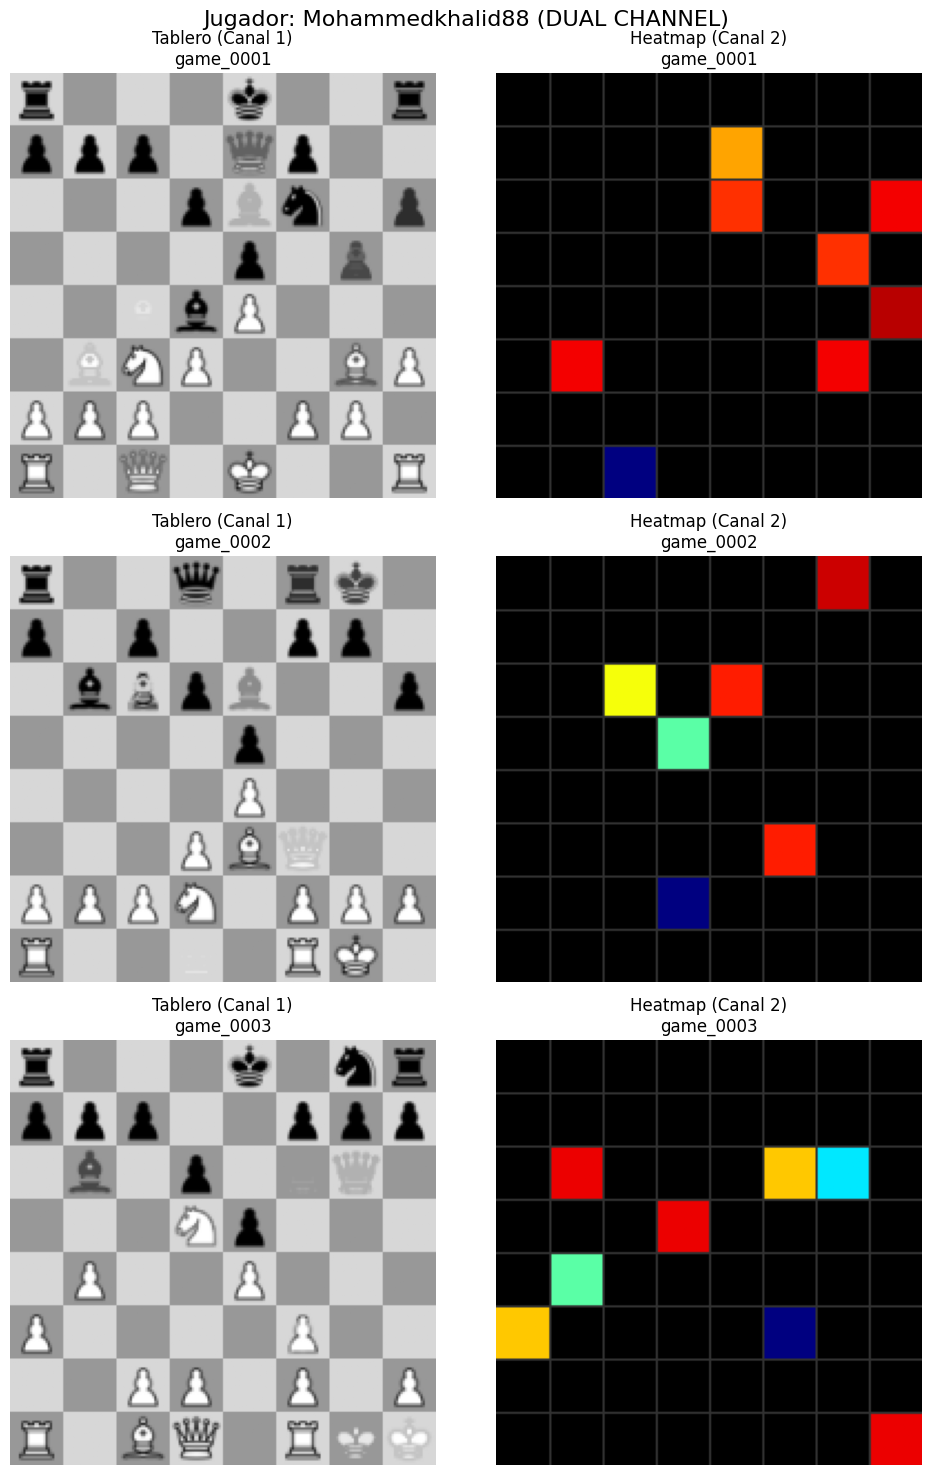


✓ Visualizados 3 pares


In [ ]:
player = random.choice(players)
player_board_dir = board_dir / player
player_heatmap_dir = heatmap_dir / player

board_imgs = sorted(list(player_board_dir.glob('*.png')))
heatmap_imgs = sorted(list(player_heatmap_dir.glob('*.png')))

print(f"\nJugador seleccionado: {player}")
print(f"  Tableros: {len(board_imgs)}")
print(f"  Heatmaps: {len(heatmap_imgs)}")

# Emparejar
pairs = []
for heat in heatmap_imgs[:3]:
    game_id = heat.stem.split('_')[1]
    matching_boards = [b for b in board_imgs if game_id in b.stem]
    if matching_boards:
        pairs.append((matching_boards[0], heat))

if len(pairs) == 0:
    # Estrategia alternativa
    num_pairs = min(3, len(board_imgs), len(heatmap_imgs))
    for i in range(num_pairs):
        pairs.append((board_imgs[i], heatmap_imgs[i]))

# Visualizar SEPARADO
if len(pairs) > 0:
    fig, axes = plt.subplots(len(pairs), 2, figsize=(10, 5*len(pairs)))
    if len(pairs) == 1:
        axes = axes.reshape(1, -1)

    for i, (board_path, heat_path) in enumerate(pairs):
        board = load_board(board_path)
        heat = load_heatmap(heat_path)
        
        axes[i, 0].imshow(board)
        axes[i, 0].set_title(f"Tablero (Canal 1)\n{board_path.stem}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(heat)
        axes[i, 1].set_title(f"Heatmap (Canal 2)\n{heat_path.stem}")
        axes[i, 1].axis('off')

    plt.suptitle(f"Jugador: {player} (DUAL CHANNEL)", fontsize=16)
    plt.tight_layout()
    plt.show()
    
    print(f"\nVisualizados {len(pairs)} pares")
else:
    print("\nNo hay imágenes para visualizar")

## 5. Preparación del Dataset

In [11]:
# (Similar a 0002a)
dataset_by_player = {}

for player in players:
    player_board_dir = board_dir / player
    player_heatmap_dir = heatmap_dir / player
    
    board_imgs = sorted(list(player_board_dir.glob('*.png')))
    heatmap_imgs = sorted(list(player_heatmap_dir.glob('*.png')))
    
    pairs = []
    for heat in heatmap_imgs:
        game_id = heat.stem.split('_')[1]
        matching_boards = [b for b in board_imgs if game_id in b.stem]
        if matching_boards:
            board = random.choice(matching_boards)
            pairs.append((board, heat))
    
    dataset_by_player[player] = pairs
    print(f"{player}: {len(pairs)} pares")

print(f"\n✓ Dataset preparado: {len(dataset_by_player)} jugadores")

Abdullah_850: 28 pares
Ashikkis: 28 pares
BainazarKazbek1996: 31 pares
BasmacH45: 27 pares
Ben-gunn: 30 pares
Berlepsch: 0 pares
BhaweshSharma: 29 pares
CHAMP_68: 28 pares
CHESSmagicians: 28 pares
CoachJohn: 31 pares
DJ_Tabooli: 26 pares
Diletant3: 29 pares
Eilia2000: 29 pares
Emily_1324: 31 pares
Evarion: 24 pares
Fabra_07: 26 pares
Hakaan911: 31 pares
Imam75: 30 pares
Insane_Gaming: 29 pares
Ivanor304l: 21 pares
Jack_strife89: 29 pares
Jhoan2765: 21 pares
Kalcole97: 32 pares
Krsticcc: 26 pares
Leonamantedelajedrez: 9 pares
LocustPizzaman: 18 pares
Maks-RF: 23 pares
Manu97190: 22 pares
MarcDave: 29 pares
MiReino: 29 pares
Mieldepalma: 27 pares
Mininina: 15 pares
Mohammedkhalid88: 28 pares
Morocco27: 0 pares
NRNK: 25 pares
Nugzar1958: 26 pares
Nunmawia: 28 pares
Orasion: 20 pares
Ostrazzo_78: 29 pares
Porthos76: 24 pares
Prasy92: 29 pares
ProKopych78: 16 pares
QuickLetsWasteTime: 22 pares
R_137: 29 pares
Ragheed07: 27 pares
RealBethHarmon: 26 pares
Rook2025: 27 pares
SACSAG1998: 26 par

In [ ]:
def generate_triplets(dataset_by_player, num_triplets=1000):
    """
    Genera triplets para entrenamiento.
    
    Returns
    -------
    triplets : list of tuples
        [(anchor_path_tuple, pos_path_tuple, neg_path_tuple), ...]
    """
    triplets = []
    
    # FILTRAR jugadores con al menos 2 pares
    valid_players = {p: pairs for p, pairs in dataset_by_player.items() if len(pairs) >= 2}
    
    if len(valid_players) < 2:
        print(f"\nERROR: Se necesitan al menos 2 jugadores con 2+ pares")
        print(f"  Jugadores válidos: {len(valid_players)}")
        print(f"  Mínimo requerido: 2")
        return []
    
    player_names = list(valid_players.keys())
    print(f"\nJugadores válidos para triplets: {len(player_names)}/{len(dataset_by_player)}")
    
    attempts = 0
    max_attempts = num_triplets * 10  # Evitar loop infinito
    
    while len(triplets) < num_triplets and attempts < max_attempts:
        attempts += 1
        
        # Seleccionar jugador anchor
        anchor_player = random.choice(player_names)
        anchor_pairs = valid_players[anchor_player]
        
        # Anchor y positive del mismo jugador
        anchor_pair, pos_pair = random.sample(anchor_pairs, 2)
        
        # Negative de otro jugador (asegurar que tenga pares)
        other_players = [p for p in player_names if p != anchor_player]
        if not other_players:
            continue
        
        neg_player = random.choice(other_players)
        neg_pairs = valid_players[neg_player]
        
        if len(neg_pairs) == 0:
            continue
        
        neg_pair = random.choice(neg_pairs)
        
        triplets.append((anchor_pair, pos_pair, neg_pair))
    
    if len(triplets) < num_triplets:
        print(f"\n⚠ Solo se generaron {len(triplets)}/{num_triplets} triplets")
        print(f"  Esto puede pasar si hay pocos jugadores o pares")
    
    return triplets

# Generar triplets
NUM_TRAIN = 2000
NUM_VAL = 500

train_triplets = generate_triplets(dataset_by_player, NUM_TRAIN)
val_triplets = generate_triplets(dataset_by_player, NUM_VAL)

print(f"\nTriplets generados:")
print(f"  Train: {len(train_triplets)}")
print(f"  Val:   {len(val_triplets)}")


Jugadores válidos para triplets: 98/100

Jugadores válidos para triplets: 98/100

Triplets generados:
  Train: 2000
  Val:   500


In [13]:
def triplet_generator_dual(triplets, batch_size=32, shuffle=True):
    """
    Generador DUAL: retorna (boards, heatmaps) separados.
    """
    while True:
        if shuffle:
            random.shuffle(triplets)
        
        for i in range(0, len(triplets), batch_size):
            batch = triplets[i:i+batch_size]
            
            anchor_boards, anchor_heats = [], []
            pos_boards, pos_heats = [], []
            neg_boards, neg_heats = [], []
            
            for anchor_pair, pos_pair, neg_pair in batch:
                # Anchor
                anchor_boards.append(load_board(anchor_pair[0]))
                anchor_heats.append(load_heatmap(anchor_pair[1]))
                
                # Positive
                pos_boards.append(load_board(pos_pair[0]))
                pos_heats.append(load_heatmap(pos_pair[1]))
                
                # Negative
                neg_boards.append(load_board(neg_pair[0]))
                neg_heats.append(load_heatmap(neg_pair[1]))
            
            yield (
                # Anchor
                (np.array(anchor_boards), np.array(anchor_heats)),
                # Positive
                (np.array(pos_boards), np.array(pos_heats)),
                # Negative
                (np.array(neg_boards), np.array(neg_heats))
            )

print("✓ Generador DUAL definido")

✓ Generador DUAL definido


## 6. Modelo Dual Channel

Dos encoders independientes + fusión de embeddings

In [14]:
class DualChannelEmbedding(Model):
    """
    Encoder dual: tablero y heatmap procesados separadamente.
    """
    def __init__(self):
        super().__init__()
        
        # Encoder para tableros
        base_board = resnet.ResNet50(
            weights="imagenet",
            input_shape=IMG_SHAPE + (3,),
            include_top=False
        )
        for layer in base_board.layers[:-10]:
            layer.trainable = False
        
        self.board_encoder = tf.keras.Sequential([
            base_board,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128)
        ], name="board_encoder")
        
        # Encoder para heatmaps
        base_heat = resnet.ResNet50(
            weights="imagenet",
            input_shape=IMG_SHAPE + (3,),
            include_top=False
        )
        for layer in base_heat.layers[:-10]:
            layer.trainable = False
        
        self.heatmap_encoder = tf.keras.Sequential([
            base_heat,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.3),
            layers.Dense(128)
        ], name="heatmap_encoder")
        
        # Fusión de embeddings
        self.combiner = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.2),
            layers.Dense(64)
        ], name="combiner")
    
    def call(self, inputs):
        board_img, heatmap_img = inputs
        
        # Procesar independientemente
        board_emb = self.board_encoder(board_img)
        heat_emb = self.heatmap_encoder(heatmap_img)
        
        # Fusionar
        combined = tf.concat([board_emb, heat_emb], axis=1)
        final_emb = self.combiner(combined)
        
        return tf.nn.l2_normalize(final_emb, axis=1)

embedding_model = DualChannelEmbedding()

dummy_board = tf.zeros((1,) + IMG_SHAPE + (3,))
dummy_heatmap = tf.zeros((1,) + IMG_SHAPE + (3,))
_ = embedding_model([dummy_board, dummy_heatmap])

print("✓ Modelo Dual Channel creado")
print(f"  Board encoder:   {embedding_model.board_encoder.count_params():,}")
print(f"  Heatmap encoder: {embedding_model.heatmap_encoder.count_params():,}")
print(f"  Combiner:        {embedding_model.combiner.count_params():,}")

I0000 00:00:1763106704.892179  492721 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22502 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:02:00.0, compute capability: 8.6
2025-11-14 07:51:50.828851: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


✓ Modelo Dual Channel creado
  Board encoder:   24,146,176
  Heatmap encoder: 24,146,176
  Combiner:        41,664


In [15]:
class SiameseModelDual(Model):
    def __init__(self, embedding_model, margin=1.0):
        super().__init__()
        self.embedding_model = embedding_model
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")
    
    def call(self, inputs):
        anchor, positive, negative = inputs
        anchor_emb = self.embedding_model(anchor)
        pos_emb = self.embedding_model(positive)
        neg_emb = self.embedding_model(negative)
        return anchor_emb, pos_emb, neg_emb
    
    def train_step(self, data):
        anchor, positive, negative = data
        
        with tf.GradientTape() as tape:
            anchor_emb, pos_emb, neg_emb = self([anchor, positive, negative])
            
            pos_dist = tf.reduce_sum(tf.square(anchor_emb - pos_emb), axis=1)
            neg_dist = tf.reduce_sum(tf.square(anchor_emb - neg_emb), axis=1)
            loss = tf.maximum(pos_dist - neg_dist + self.margin, 0.0)
            loss = tf.reduce_mean(loss)
        
        gradients = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_variables))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    
    @property
    def metrics(self):
        return [self.loss_tracker]

siamese_model = SiameseModelDual(embedding_model, margin=1.0)
siamese_model.compile(optimizer=optimizers.Adam(learning_rate=1e-4))
print("✓ Modelo Siamés Dual compilado")

✓ Modelo Siamés Dual compilado


## 7. Entrenamiento

In [24]:
train_gen = triplet_generator_dual(train_triplets, BATCH_SIZE, shuffle=True)
val_gen = triplet_generator_dual(val_triplets, BATCH_SIZE, shuffle=False)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'best_model_dual_channel.keras',
        monitor='loss',
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

history = siamese_model.fit(
    train_gen,
    steps_per_epoch=len(train_triplets) // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print("\n✓ Entrenamiento completado")

Epoch 1/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.5611
Epoch 1: loss improved from None to 0.56662, saving model to best_model_dual_channel.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 224ms/step - loss: 0.5666 - learning_rate: 5.0000e-05
Epoch 2/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.5491
Epoch 2: loss improved from 0.56662 to 0.56215, saving model to best_model_dual_channel.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 222ms/step - loss: 0.5622 - learning_rate: 5.0000e-05
Epoch 3/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - loss: 0.6033
Epoch 3: loss did not improve from 0.56215
62/62 ━━━━━━━━━━━━━━━━━━━━ 10s 165ms/step - loss: 0.5689 - learning_rate: 5.0000e-05
Epoch 4/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - loss: 0.5414
Epoch 4: loss improved from 0.56215 to 0.54597, saving model to best_model_dual_channel.keras
62/62 ━━━━━━━━━━━━━━━━━━━━ 14s 227ms/step - loss: 0.5460 - learning_rate: 5.0000e-05
Epoch 5/50
62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - loss: 0.5368
Epo

## 8. Visualización del Entrenamiento

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Evolución del Loss - Dual Channel CNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Evaluación

In [18]:
val_anchor_boards, val_anchor_heats = [], []
val_pos_boards, val_pos_heats = [], []
val_neg_boards, val_neg_heats = [], []

for anchor_pair, pos_pair, neg_pair in val_triplets[:100]:
    val_anchor_boards.append(load_board(anchor_pair[0]))
    val_anchor_heats.append(load_heatmap(anchor_pair[1]))
    
    val_pos_boards.append(load_board(pos_pair[0]))
    val_pos_heats.append(load_heatmap(pos_pair[1]))
    
    val_neg_boards.append(load_board(neg_pair[0]))
    val_neg_heats.append(load_heatmap(neg_pair[1]))

anchor_embs = embedding_model((np.array(val_anchor_boards), np.array(val_anchor_heats)))
pos_embs = embedding_model((np.array(val_pos_boards), np.array(val_pos_heats)))
neg_embs = embedding_model((np.array(val_neg_boards), np.array(val_neg_heats)))

pos_dists = tf.reduce_sum(tf.square(anchor_embs - pos_embs), axis=1).numpy()
neg_dists = tf.reduce_sum(tf.square(anchor_embs - neg_embs), axis=1).numpy()

print(f"\nDistancias anchor↔positive:")
print(f"  Media: {pos_dists.mean():.4f} ± {pos_dists.std():.4f}")
print(f"\nDistancias anchor↔negative:")
print(f"  Media: {neg_dists.mean():.4f} ± {neg_dists.std():.4f}")
print(f"\nRatio (neg/pos): {neg_dists.mean() / pos_dists.mean():.2f}x")


Distancias anchor↔positive:
  Media: 0.7403 ± 0.6052

Distancias anchor↔negative:
  Media: 1.2085 ± 0.8138

Ratio (neg/pos): 1.63x


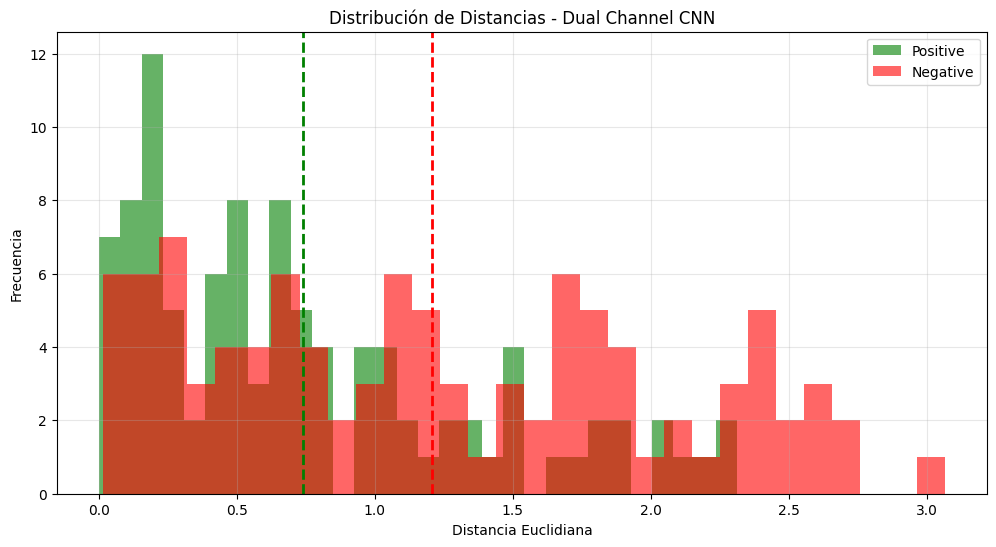

In [19]:
plt.figure(figsize=(12, 6))
plt.hist(pos_dists, bins=30, alpha=0.6, label='Positive', color='green')
plt.hist(neg_dists, bins=30, alpha=0.6, label='Negative', color='red')
plt.axvline(pos_dists.mean(), color='green', linestyle='--', linewidth=2)
plt.axvline(neg_dists.mean(), color='red', linestyle='--', linewidth=2)
plt.xlabel('Distancia Euclidiana')
plt.ylabel('Frecuencia')
plt.title('Distribución de Distancias - Dual Channel CNN')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 10. Matriz de Distancias entre Jugadores

In [ ]:
player_embeddings = {}

for player in players:
    pairs = dataset_by_player[player][:10]
    embeddings = []
    
    for board_path, heat_path in pairs:
        board = load_board(board_path)[np.newaxis, ...]
        heat = load_heatmap(heat_path)[np.newaxis, ...]
        emb = embedding_model((board, heat))
        embeddings.append(emb.numpy())
    
    player_embeddings[player] = np.mean(embeddings, axis=0)

n_players = len(players)
dist_matrix = np.zeros((n_players, n_players))

for i, p1 in enumerate(players):
    for j, p2 in enumerate(players):
        dist = np.sum((player_embeddings[p1] - player_embeddings[p2])**2)
        dist_matrix[i, j] = dist

plt.figure(figsize=(12, 10))
plt.imshow(dist_matrix, cmap='hot', interpolation='nearest')
plt.colorbar(label='Distancia')
plt.xticks(range(n_players), [p[:15] for p in players], rotation=90, fontsize=8)
plt.yticks(range(n_players), [p[:15] for p in players], fontsize=8)
plt.title('Matriz de Distancias - Dual Channel CNN')
plt.tight_layout()
plt.show()

/home/andrewyernau/dev/jupyter/venv/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/andrewyernau/dev/jupyter/venv/lib/python3.12/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


## 11. Conclusiones


El modelo no parece aprender especialmente bien

## 12. Testing Real del Modelo

### 12.1 Preparar Dataset de Test (si no existe)

In [21]:
all_players = list(dataset_by_player.keys())
num_test_players = max(1, len(all_players) // 5)  # 20% para test
test_players = random.sample(all_players, num_test_players)

print(f"Jugadores para test: {num_test_players}/{len(all_players)}")
print(f"Test players: {test_players[:5]}...")

Jugadores para test: 20/100
Test players: ['Jhoan2765', 'Porthos76', 'yvesanje', 'Eilia2000', 'Ivanor304l']...


In [22]:
import random
import os

def predecir_jugador(model, jugador_id, dataset_by_player, threshold=0.5):
    """
    Predice si un jugador es conocido o desconocido y su identidad.
    
    Args:
        model: Modelo entrenado (DualChannelCNN)
        jugador_id: ID del jugador a probar (nombre del jugador)
        dataset_by_player: Diccionario {player: [(board, heatmap), ...]}
        threshold: Umbral de distancia para considerar match
    
    Returns:
        dict con resultados de la predicción
    """
    # Verificar que el jugador existe
    if jugador_id not in dataset_by_player:
        return {"error": f"Jugador {jugador_id} no encontrado en el dataset"}
    
    # Obtener pares (board, heatmap) del jugador
    jugador_pairs = dataset_by_player[jugador_id]
    
    if len(jugador_pairs) < 2:
        return {"error": "No hay suficientes imágenes para este jugador"}
    
    # Seleccionar una imagen query (la última) y el resto como galería
    query_board, query_heatmap = jugador_pairs[-1]
    
    # Convertir a formato modelo (añadir batch dimension)
    query_board_batch = np.expand_dims(query_board, axis=0)
    query_heatmap_batch = np.expand_dims(query_heatmap, axis=0)
    
    # Obtener embedding de la imagen query
    query_emb = model.predict([query_board_batch, query_heatmap_batch], verbose=0)
    
    # Calcular distancias con todos los jugadores en la galería
    resultados = []
    
    for pid, pairs in dataset_by_player.items():
        if pid == jugador_id:
            # Para el mismo jugador, usar imágenes diferentes (todas excepto la query)
            gallery_pairs = pairs[:-1]
        else:
            # Para otros jugadores, usar todas sus imágenes
            gallery_pairs = pairs
        
        if not gallery_pairs:
            continue
            
        distancias = []
        # Limitar a máximo 5 imágenes por jugador para eficiencia
        for board, heatmap in gallery_pairs[:5]:
            board_batch = np.expand_dims(board, axis=0)
            heatmap_batch = np.expand_dims(heatmap, axis=0)
            
            gallery_emb = model.predict([board_batch, heatmap_batch], verbose=0)
            
            # Calcular distancia euclidiana
            dist = np.linalg.norm(query_emb - gallery_emb)
            distancias.append(dist)
        
        dist_promedio = np.mean(distancias)
        resultados.append({
            'player_id': pid,
            'distancia': dist_promedio,
            'num_comparaciones': len(distancias)
        })
    
    # Ordenar por distancia (menor = más similar)
    resultados.sort(key=lambda x: x['distancia'])
    
    mejor_match = resultados[0]
    es_correcto = mejor_match['player_id'] == jugador_id
    
    return {
        'jugador_real': jugador_id,
        'prediccion': mejor_match['player_id'],
        'distancia_minima': mejor_match['distancia'],
        'es_correcto': es_correcto,
        'confianza': 1 - (mejor_match['distancia'] / threshold) if mejor_match['distancia'] < threshold else 0,
        'top_5_matches': resultados[:5],
        'es_conocido': mejor_match['distancia'] < threshold
    }

In [23]:
num_pruebas = 10

# Opción 1: Usar jugadores separados para test
if 'test_players' in locals():
    jugadores_a_probar = test_players[:num_pruebas]
else:
    # Opción 2: Seleccionar random de todos los jugadores
    all_players = list(dataset_by_player.keys())
    jugadores_a_probar = random.sample(all_players, min(num_pruebas, len(all_players)))

resultados_pruebas = []

print("=" * 80)
print("PRUEBAS DE PREDICCIÓN CON JUGADORES RANDOM")
print("=" * 80)
print(f"Jugadores a probar: {jugadores_a_probar}\n")

for idx, jugador_id in enumerate(jugadores_a_probar, 1):
    print(f"\n[{idx}/{num_pruebas}] Probando jugador: {jugador_id}")
    resultado = predecir_jugador(embedding_model, jugador_id, dataset_by_player, threshold=1.0)
    
    if 'error' not in resultado:
        resultados_pruebas.append(resultado)
        
        print(f"  ✓ Predicción: {resultado['prediccion']}")
        print(f"  ✓ Distancia: {resultado['distancia_minima']:.4f}")
        print(f"  ✓ Correcto: {'✅ SÍ' if resultado['es_correcto'] else '❌ NO'}")
        print(f"  ✓ Confianza: {resultado['confianza']:.2%}")
        print(f"  ✓ Conocido: {'✅ SÍ' if resultado['es_conocido'] else '❌ NO (Desconocido)'}")
        
        if not resultado['es_correcto']:
            print(f"  ⚠️  Top 3 matches:")
            for i, match in enumerate(resultado['top_5_matches'][:3], 1):
                print(f"     {i}. Player {match['player_id']}: {match['distancia']:.4f}")

# Calcular métricas globales
accuracy = sum(r['es_correcto'] for r in resultados_pruebas) / len(resultados_pruebas)
confianza_promedio = np.mean([r['confianza'] for r in resultados_pruebas])

print("\n" + "=" * 80)
print("RESULTADOS GLOBALES")
print("=" * 80)
print(f"Accuracy: {accuracy:.2%}")
print(f"Confianza promedio: {confianza_promedio:.2%}")
print(f"Correctos: {sum(r['es_correcto'] for r in resultados_pruebas)}/{len(resultados_pruebas)}")

PRUEBAS DE PREDICCIÓN CON JUGADORES RANDOM
Jugadores a probar: ['Jhoan2765', 'Porthos76', 'yvesanje', 'Eilia2000', 'Ivanor304l', 'Leonamantedelajedrez', 'DJ_Tabooli', 'dugyaafel', 'Sensey12345', 'Hakaan911']


[1/10] Probando jugador: Jhoan2765


ValueError: Invalid dtype: object